### Human In The Loop

In [2]:
import os
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = init_chat_model("groq:qwen/qwen3-32b")

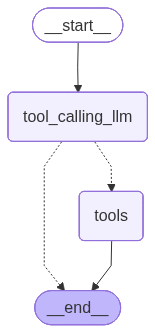

In [5]:
### StateGraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import display, Image

# Node Definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)

builder.add_edge("tools",END)

##Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

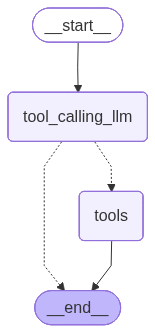

In [7]:
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, Interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query : str) -> str:
    """ Request assistance from a human """
    human_response = Interrupt({"query":query})
    return human_response["data"]

tool = TavilySearch(max_results = 2)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

def chatbot(state : State):
    message = llm_with_tools.invoke(state["messages"])
    return {"messages":[message]}

graph_builder.add_node("chatbot",chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges("chatbot",tools_condition)

graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))



In [ ]:
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me
================================== Ai Message ==================================
Tool Calls:
  human_assistance (xw30nkqyk)
 Call ID: xw30nkqyk
  Args:
    query: I need some expert guidance for building an AI agent.


TypeError: 'Interrupt' object is not subscriptable

: 